In [5]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from fizinfo import *

In [6]:
def create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g=9.81):

    # konstans tömeg
    def mass_fun(t):   # formai okokból kell a t de ettől nem függ ez a tömeg
        return m

    def force_fun(t, r, v, m):  # formai okokból kell a t, r, v de egyiktől sem függ ez az erőfüggvény
        """Gravitációs erő y irányban és v^2-teal arányos közegellenállási erő eredője
        + talaj felfele ható és fékező ereje."""
        
        F_work=np.array([0.0, -m*g], np.float64)  # grav erő
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs # közegell. erő hatása

        if r[1]<0.0:  # elértük a talajt
            F_work+=np.array([0.0, -D*r[1]])  # rugalmas erő felfele
            F_work-=F_f*v/np.maximum(v_abs, 1e-10)
    
        return F_work

    return force_fun, mass_fun

In [14]:
def stop_ground_y(r, v):
    """Leállás y<0 esetén"""
    
    return r[1]<0.0


m_ball=0.0027   
d_ball=0.040 

r=d_ball/2
A=np.pi*r**2
C=0.47 # gömb
rho=1.3 # levegő sűrűség
g=9.81

D=1000.0  # 
F_f=0.2   # egy kis fékeződés a talajjal való érintkezés során

F_ball, m_ball= create_grav_közeg_talaj_F_m(m_ball, C, A, rho, D, F_f, g)

In [17]:
# a)
x0=0.0
y0=25.0
v0x=0.0
v0y=0.0

ejtes=num_dinam(2)
ejtes.set_time_range(0.0, 20.0, 0.001)
ejtes.set_mass_fun(m_ball)
ejtes.set_F_fun(F_ball)   
ejtes.set_r0_v0([x0, y0], [v0x, v0y])
ejtes.set_stop_cond(stop_ground_y)   # A fgeladat szerint csak a földet érésig kell számolni!

ejtes.full_dinam_calc()

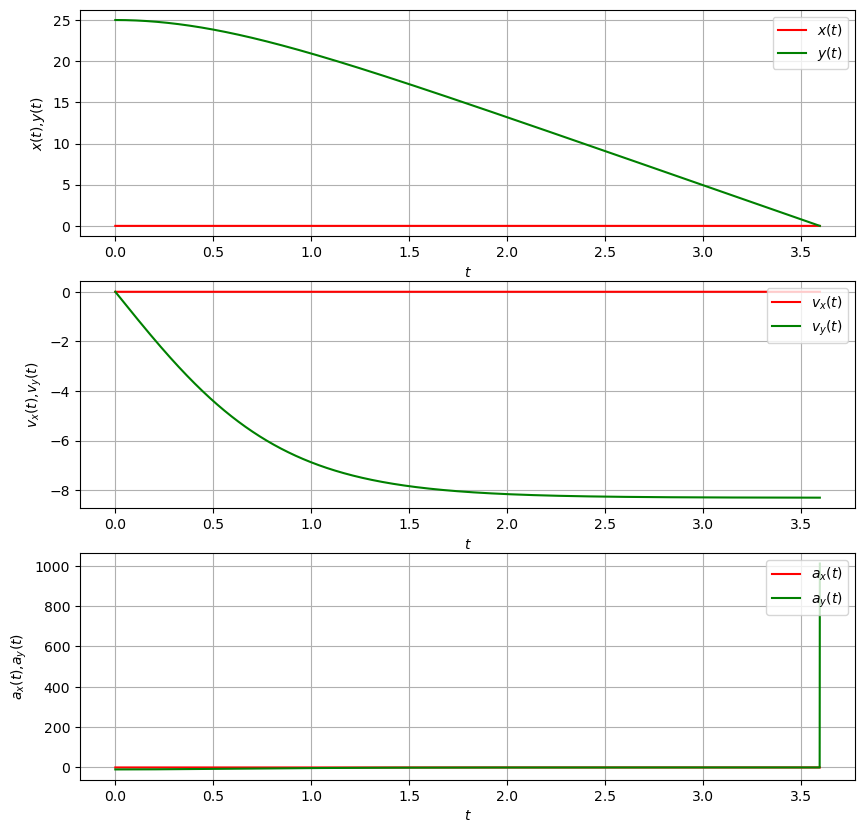

In [18]:
ejtes.plot_rva_coord()

In [19]:
# b)

In [20]:
# kezdőértékek
x0=0.0
y0=1.1
v0=40/3.6
alpha_deg=30.0
v0_x=v0*np.cos(np.radians(alpha_deg))
v0_y=v0*np.sin(np.radians(alpha_deg))


# dinamikai számítások
dobas=num_dinam(2)
dobas.set_time_range(0.0, 20.0, 0.001)
dobas.set_mass_fun(m_ball)
dobas.set_F_fun(F_ball)   
dobas.set_r0_v0([x0, y0], [v0_x, v0_y])

dobas.full_dinam_calc()

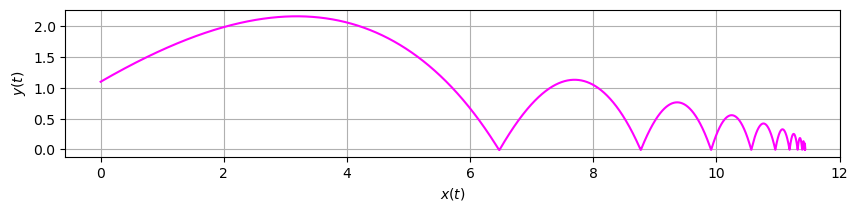

In [22]:
dobas.plot_rcomp()

In [7]:
# c)

In [28]:
y_work=dobas.r[:,1]
vabs_work=vect_abs(dobas.v)

arg_talaj=arg_eq(y_work, 0.0)
# ezek duplák: a talajra érés és az elszakadás ideje is! Csak a v_y<0.0 maradhat

for arg in arg_talaj:
    if dobas.v[arg,1]>0.0:
        continue
    tt=dobas.t[arg]
    xx=dobas.r[arg,0]
    vvabs=vabs_work[arg]
    
    print(f"{tt:.2f}\t{xx:.3f}\t{vvabs:.3f}")
    
    


1.16	6.465	6.303
2.12	8.766	4.689
2.92	9.910	3.855
3.59	10.563	3.283
4.19	10.955	2.853
4.71	11.186	2.506
5.17	11.318	2.196
5.56	11.392	1.886
5.90	11.431	1.609
6.19	11.441	1.373
6.43	11.436	1.145
6.62	11.434	0.911
6.77	11.434	0.678
6.86	11.436	0.439
6.90	11.436	0.131
6.91	11.436	0.007
6.92	11.436	0.060
6.93	11.436	0.011
6.94	11.436	0.056
6.94	11.436	0.022
6.96	11.436	0.052
6.96	11.436	0.015
6.98	11.436	0.055
6.98	11.436	0.017
7.00	11.436	0.052
7.00	11.436	0.024
7.01	11.436	0.046
7.02	11.436	0.017
7.03	11.436	0.053
7.04	11.436	0.013
7.05	11.436	0.053
7.06	11.436	0.011
7.07	11.436	0.060
7.08	11.436	0.019
7.09	11.436	0.058
7.10	11.436	0.015
7.11	11.436	0.052
7.12	11.436	0.022
7.13	11.436	0.037
7.13	11.436	0.047
7.13	11.436	0.011
7.14	11.436	0.021
7.15	11.436	0.041
7.15	11.436	0.025
7.16	11.436	0.042
7.17	11.436	0.021
7.18	11.436	0.054
7.19	11.436	0.020
7.20	11.436	0.046
7.21	11.436	0.026
7.22	11.436	0.038
7.22	11.436	0.048
7.22	11.436	0.006
7.22	11.436	0.016
7.23	11.436	0.040
7.24	11.436	0

In [9]:
ball_din.v_abs=vect_abs(ball_din.v)

print("Az első talaj-leérés:")
print(f"  - ideje: {ball_din.t[arg_talaj0]:.2f} s.")
print(f"  - x koord: {ball_din.r[arg_talaj0,0]:.2f} m.")
print(f"  - sebessége: {ball_din.v_abs[arg_talaj0]:.2f} m/s.")

Az első talaj-leérés:
  - ideje: 1.52 s.
  - x koord: 10.14 m.
  - sebessége: 9.96 m/s.


In [29]:
# d)

In [30]:
def dobastav(v0):
    
    x0=0.0
    y0=1.1
    alpha_deg=30.0
    v0_x=v0*np.cos(np.radians(alpha_deg))
    v0_y=v0*np.sin(np.radians(alpha_deg))


    # dinamikai számítások
    dobas=num_dinam(2)
    dobas.set_time_range(0.0, 20.0, 0.001)
    dobas.set_mass_fun(m_ball)
    dobas.set_F_fun(F_ball)   
    dobas.set_r0_v0([x0, y0], [v0_x, v0_y])

    dobas.full_dinam_calc()
    
    
    return dobas.r[-1,0]

In [37]:
v0_kmh_arr=np.arange(0.0, 100.0, 3.0)
tav_list=[]

for v0_kmh in v0_kmh_arr:
    tav=dobastav(v0_kmh/3.6)
    
    tav_list.append(tav)
    

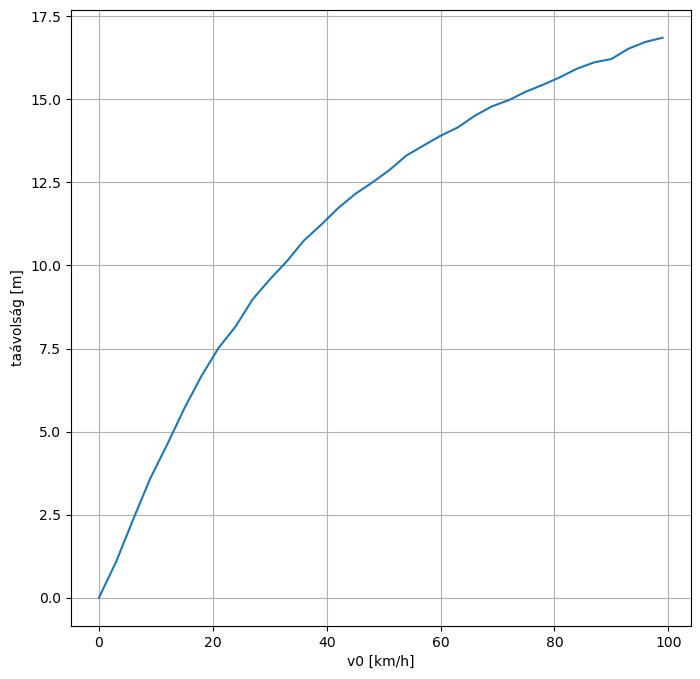

In [38]:
fig=plt.figure(figsize=(8,8))  

ax1=fig.add_subplot(111) 

ax1.plot(v0_kmh_arr, tav_list)
ax1.set_xlabel("v0 [km/h]") 
ax1.set_ylabel("taávolság [m]") 
ax1.grid()    